# FDEPH Phase 3 — Collision Attack Analysis

**Author:** Avijit Roy  
**Project:** FDEPH — Security Evaluation of Perceptual Image Hashing  
**PI:** Prof. Shweta Jain  
**Date:** March 2026  
**Status:** COMPLETE — Verified

---

### What this notebook covers
- NeuralHash collision: 500 images, ImageNette val (source) vs train (target hashset)
- pHash collision: same 500 images, same target hashset
- Head-to-head comparison: NeuralHash vs pHash on collision
- Cross-attack comparison: evasion vs collision cost for both algorithms
- All figures saved to `fdeph_eval/analysis/figures/`
- All tables saved to `fdeph_eval/analysis/tables/`

In [1]:
import os, sys
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
print("Repo root:", REPO_ROOT)

Repo root: /home/exouser/ar-sec-eval


In [2]:
import os
import io
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

# ---- Paths ------------------------------------------------------------------
NHASH_COLLISION_CSV = 'logs/nhash_collision_imagenette500.csv'
PHASH_COLLISION_CSV = 'logs/phash_collision_imagenette500.csv'

# Evasion reference data (from Phases 1 & 2, T=0.10)
NHASH_EVASION_CSV   = 'logs/attack_steps_nhash_evasion_mt500_T0.10.csv'
PHASH_EVASION_CSV   = 'logs/attack_steps_phash_evasion_mt500_T0.10.csv'

FIGURES_DIR = 'fdeph_eval/analysis/figures'
TABLES_DIR  = 'fdeph_eval/analysis/tables'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR,  exist_ok=True)

TOTAL_IMAGES = 500

# ---- Plot style -------------------------------------------------------------
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

NHASH_COLOR = '#2196F3'   # blue  — NeuralHash
PHASH_COLOR = '#FF5722'   # orange — pHash

print('Libraries loaded. Paths configured.')

Libraries loaded. Paths configured.


## 1. Load and Parse Logs

In [3]:
def load_collision_csv(filepath):
    """Parse collision attack log CSV.
    Skips timestamp line and hyperparameter row.
    Returns DataFrame with columns: file, l2, l_inf, ssim, steps.
    """
    with open(filepath) as f:
        lines = f.read().splitlines()
    # Line 0 = timestamp, Line 1 = header, Line 2 = hyperparams, Line 3+ = data
    csv_content = '\n'.join(lines[1:])
    reader = csv.DictReader(io.StringIO(csv_content))
    rows = []
    for row in reader:
        try:
            rows.append({
                'file':   row['file'],
                'l2':     float(row['l2']),
                'l_inf':  float(row['l_inf']),
                'ssim':   float(row['ssim']),
                'steps':  int(row['steps']),
            })
        except (ValueError, KeyError, TypeError):
            pass
    return pd.DataFrame(rows)


def load_evasion_csv(filepath):
    """Parse evasion attack log CSV (Phase 1/2 format)."""
    df = pd.read_csv(filepath)
    # Handle varying column names across phases
    step_col = [c for c in df.columns if 'step' in c.lower()]
    if step_col:
        df = df.rename(columns={step_col[0]: 'steps'})
    return df[df['steps'].notna()].copy()


nhash_col = load_collision_csv(NHASH_COLLISION_CSV)
phash_col = load_collision_csv(PHASH_COLLISION_CSV)

print(f'NeuralHash collision: {len(nhash_col)} / {TOTAL_IMAGES} successful ({len(nhash_col)/TOTAL_IMAGES*100:.1f}%)')
print(f'pHash collision     : {len(phash_col)} / {TOTAL_IMAGES} successful ({len(phash_col)/TOTAL_IMAGES*100:.1f}%)')
print()
print('NeuralHash collision sample:')
display(nhash_col.head(3))
print('pHash collision sample:')
display(phash_col.head(3))

NeuralHash collision: 474 / 500 successful (94.8%)
pHash collision     : 211 / 500 successful (42.2%)

NeuralHash collision sample:


,file,l2,l_inf,ssim,steps
0,/home/exouser/ar-sec-eval/inputs/inputs_500/IL...,13.727118,0.133333,0.988701,421
1,/home/exouser/ar-sec-eval/inputs/inputs_500/IL...,18.676128,0.215686,0.977462,431
2,/home/exouser/ar-sec-eval/inputs/inputs_500/IL...,13.803581,0.058824,0.979256,111


pHash collision sample:


,file,l2,l_inf,ssim,steps
0,/home/exouser/ar-sec-eval/inputs/inputs_500/IL...,10.750149,0.054902,0.994524,91
1,/home/exouser/ar-sec-eval/inputs/inputs_500/IL...,11.931969,0.070588,0.988880,121
2,/home/exouser/ar-sec-eval/inputs/inputs_500/IL...,17.305702,0.149020,0.968927,221


## 2. Summary Statistics

In [4]:
def summary_stats(df, label, total=500):
    n = len(df)
    stats = {
        'Algorithm':         label,
        'Total images':      total,
        'Successful':        n,
        'Success rate (%)':  round(n / total * 100, 1),
        'Failed':            total - n,
        'Steps median':      int(df['steps'].median()),
        'Steps mean':        round(df['steps'].mean(), 1),
        'Steps P95':         int(df['steps'].quantile(0.95)),
        'Steps max':         int(df['steps'].max()),
        'L2 median':         round(df['l2'].median(), 4),
        'L2 mean':           round(df['l2'].mean(), 4),
        'L2 max':            round(df['l2'].max(), 4),
        'L-Inf median':      round(df['l_inf'].median(), 4),
        'L-Inf mean':        round(df['l_inf'].mean(), 4),
        'L-Inf max':         round(df['l_inf'].max(), 4),
        'SSIM median':       round(df['ssim'].median(), 4),
        'SSIM mean':         round(df['ssim'].mean(), 4),
        'SSIM min':          round(df['ssim'].min(), 4),
        'SSIM >= 0.99':      int((df['ssim'] >= 0.99).sum()),
        'SSIM >= 0.95':      int((df['ssim'] >= 0.95).sum()),
        'SSIM < 0.95':       int((df['ssim'] < 0.95).sum()),
        'SSIM < 0.90':       int((df['ssim'] < 0.90).sum()),
    }
    return stats

nhash_stats = summary_stats(nhash_col, 'NeuralHash Collision')
phash_stats = summary_stats(phash_col, 'pHash Collision')

stats_df = pd.DataFrame([nhash_stats, phash_stats]).set_index('Algorithm')
display(stats_df.T)

stats_df.T.to_csv(f'{TABLES_DIR}/collision_summary_stats.csv')
print(f'Saved: {TABLES_DIR}/collision_summary_stats.csv')

Algorithm,NeuralHash Collision,pHash Collision
Total images,500.0000,500.0000
Successful,474.0000,211.0000
Success rate (%),94.8000,42.2000
Failed,26.0000,289.0000
Steps median,721.0000,171.0000
Steps mean,1247.9000,525.3000
Steps P95,4656.0000,2941.0000
Steps max,9531.0000,7051.0000
L2 median,20.0273,13.5301
L2 mean,20.9542,14.3566


Saved: fdeph_eval/analysis/tables/collision_summary_stats.csv


## 3. Steps Distribution — Histogram

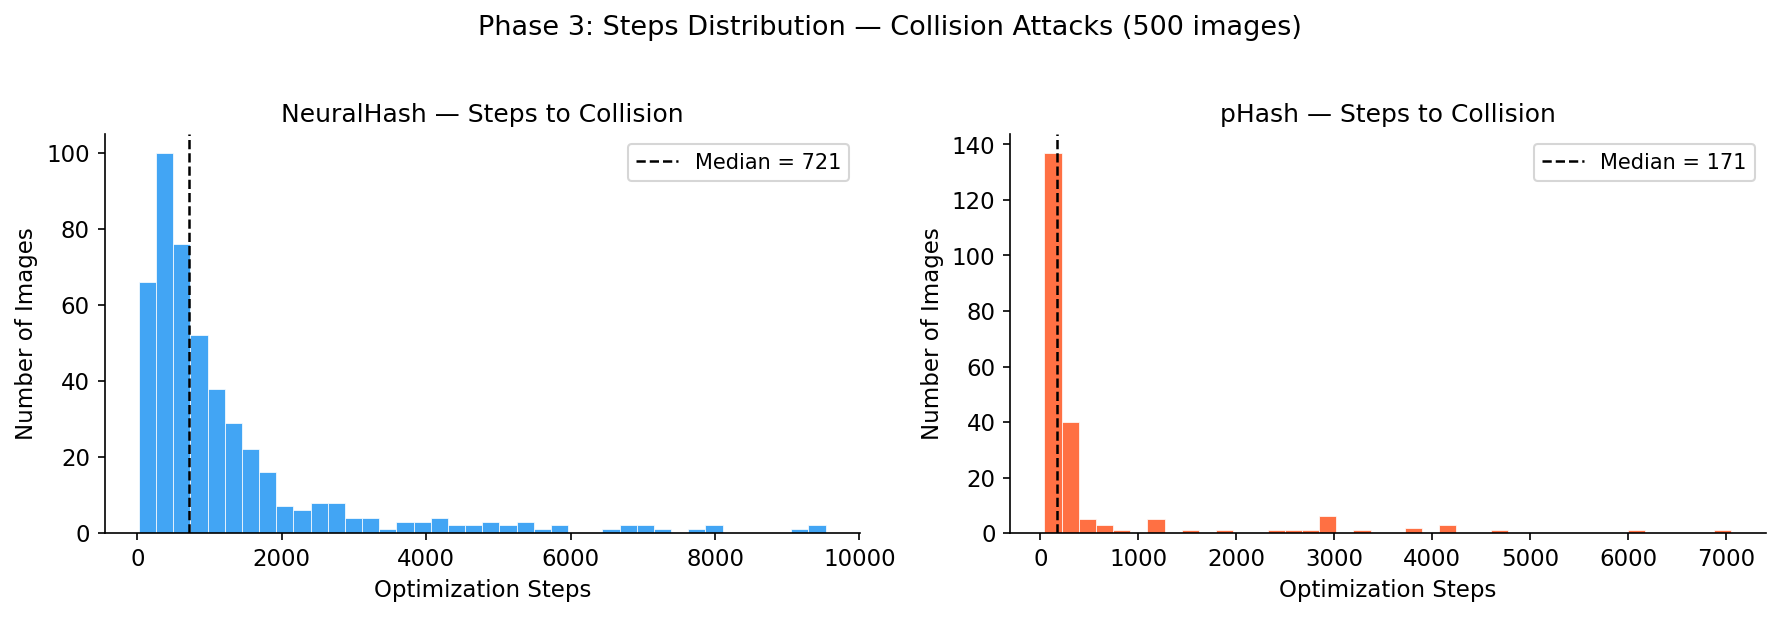

Saved: fdeph_eval/analysis/figures/collision_steps_histogram.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, df, color, label in [
    (axes[0], nhash_col, NHASH_COLOR, 'NeuralHash'),
    (axes[1], phash_col, PHASH_COLOR, 'pHash'),
]:
    ax.hist(df['steps'], bins=40, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(df['steps'].median(), color='black', linestyle='--', linewidth=1.2,
               label=f'Median = {int(df["steps"].median())}')
    ax.set_title(f'{label} — Steps to Collision')
    ax.set_xlabel('Optimization Steps')
    ax.set_ylabel('Number of Images')
    ax.legend()

fig.suptitle('Phase 3: Steps Distribution — Collision Attacks (500 images)', fontsize=13, y=1.02)
plt.tight_layout()
out = f'{FIGURES_DIR}/collision_steps_histogram.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 4. Steps CDF — Cumulative Success Rate vs Steps

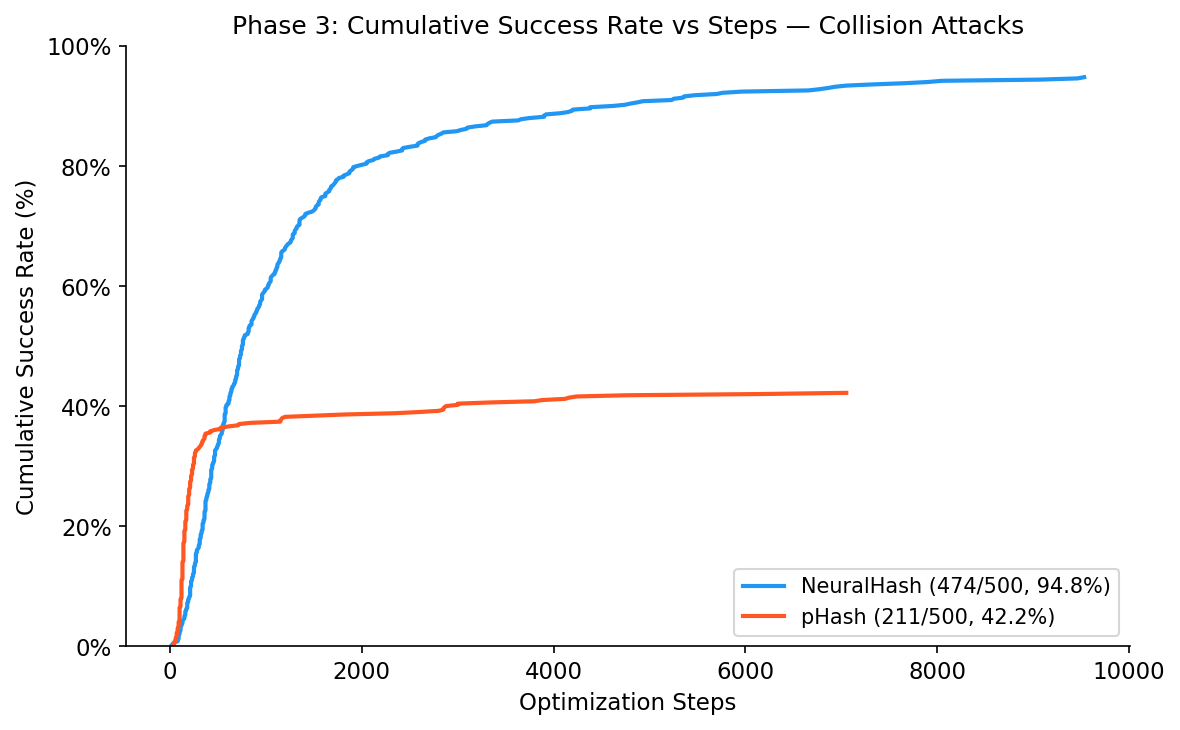

Saved: fdeph_eval/analysis/figures/collision_success_rate_vs_steps.png


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

for df, color, label, total in [
    (nhash_col, NHASH_COLOR, f'NeuralHash ({len(nhash_col)}/500, {len(nhash_col)/5:.1f}%)', TOTAL_IMAGES),
    (phash_col, PHASH_COLOR, f'pHash ({len(phash_col)}/500, {len(phash_col)/5:.1f}%)',     TOTAL_IMAGES),
]:
    sorted_steps = np.sort(df['steps'].values)
    cdf = np.arange(1, len(sorted_steps) + 1) / total
    ax.plot(sorted_steps, cdf * 100, color=color, linewidth=2, label=label)

ax.set_xlabel('Optimization Steps')
ax.set_ylabel('Cumulative Success Rate (%)')
ax.set_title('Phase 3: Cumulative Success Rate vs Steps — Collision Attacks')
ax.legend()
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
out = f'{FIGURES_DIR}/collision_success_rate_vs_steps.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 5. L2 Distortion Distribution

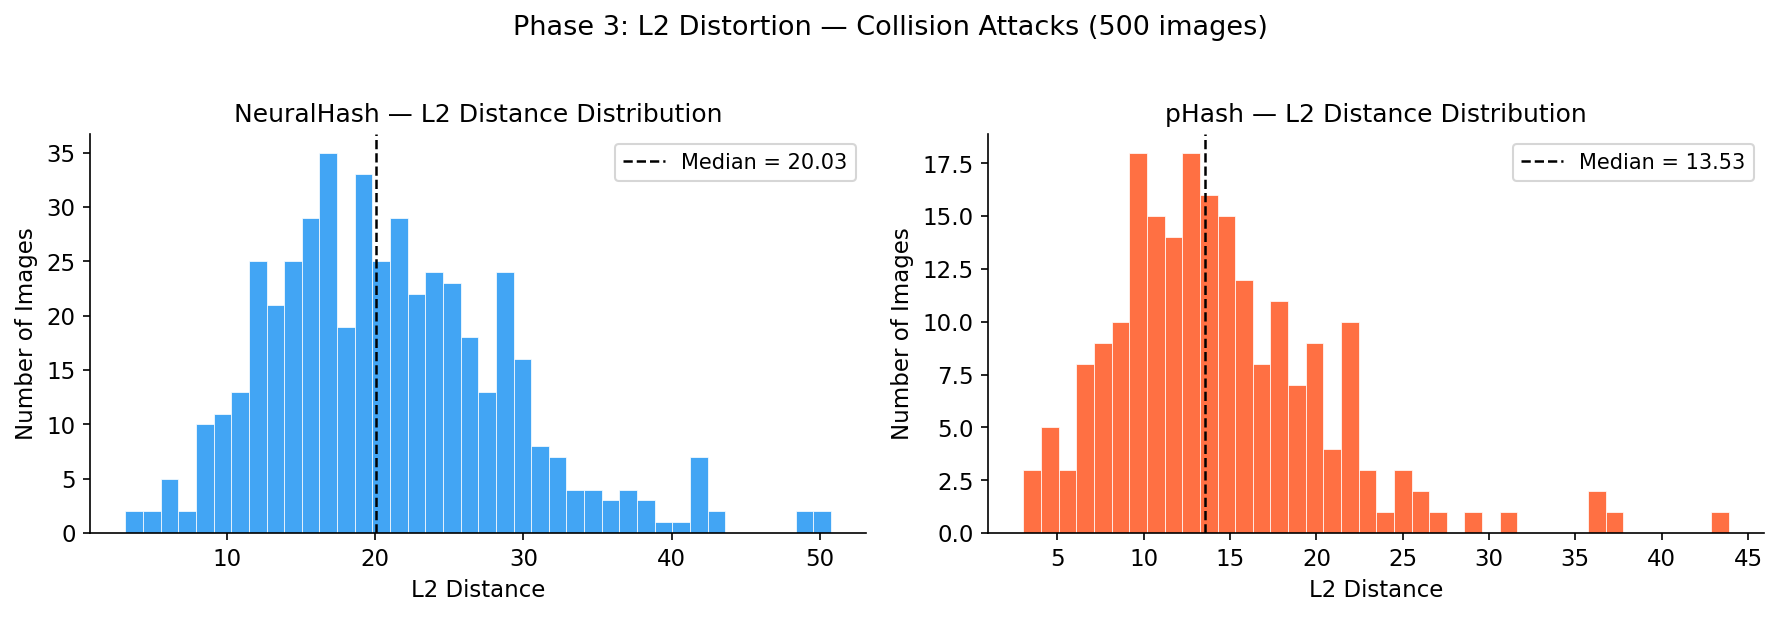

Saved: fdeph_eval/analysis/figures/collision_l2_distribution.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, color, label in [
    (axes[0], nhash_col, NHASH_COLOR, 'NeuralHash'),
    (axes[1], phash_col, PHASH_COLOR, 'pHash'),
]:
    ax.hist(df['l2'], bins=40, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(df['l2'].median(), color='black', linestyle='--', linewidth=1.2,
               label=f'Median = {df["l2"].median():.2f}')
    ax.set_title(f'{label} — L2 Distance Distribution')
    ax.set_xlabel('L2 Distance')
    ax.set_ylabel('Number of Images')
    ax.legend()

fig.suptitle('Phase 3: L2 Distortion — Collision Attacks (500 images)', fontsize=13, y=1.02)
plt.tight_layout()
out = f'{FIGURES_DIR}/collision_l2_distribution.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 6. L∞ Distortion Distribution

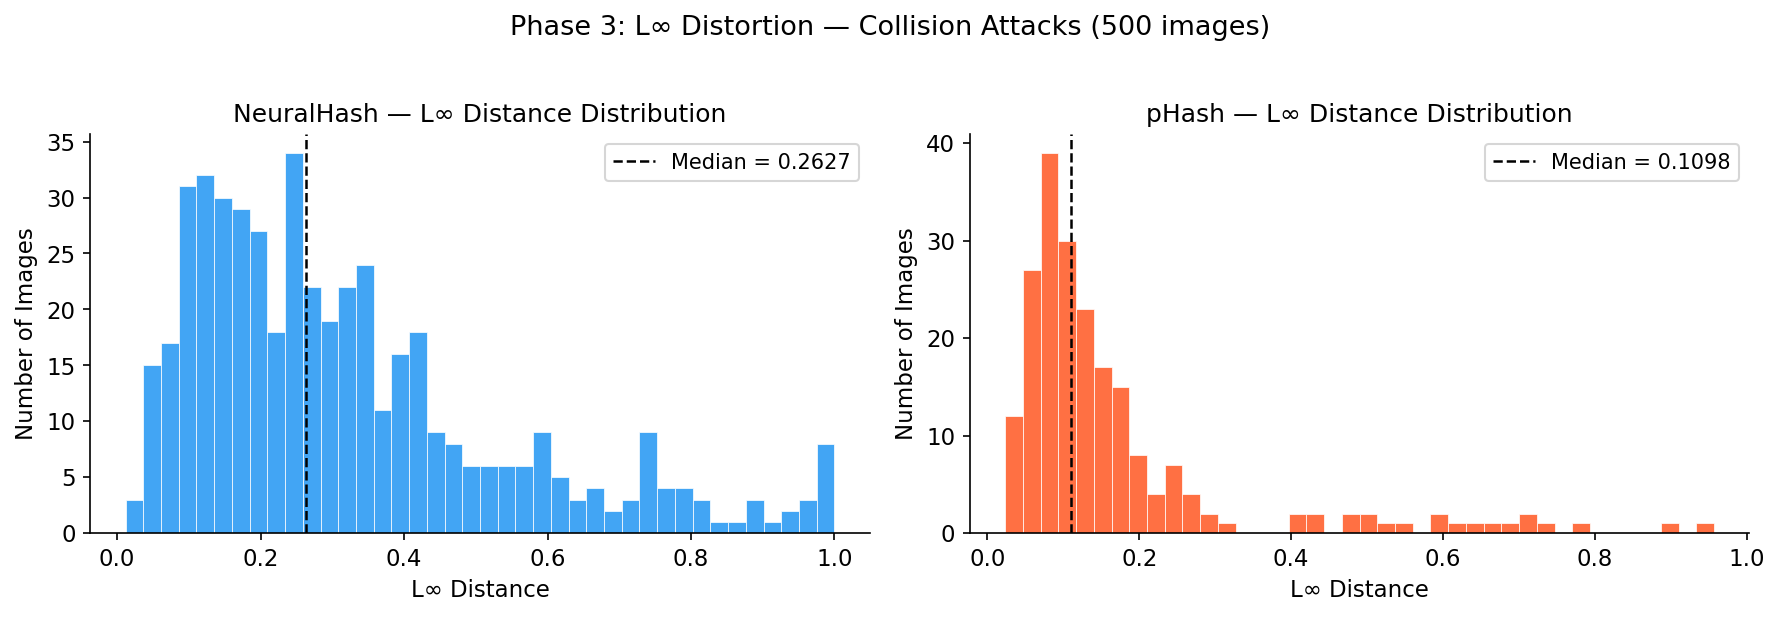

Saved: fdeph_eval/analysis/figures/collision_linf_distribution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, color, label in [
    (axes[0], nhash_col, NHASH_COLOR, 'NeuralHash'),
    (axes[1], phash_col, PHASH_COLOR, 'pHash'),
]:
    ax.hist(df['l_inf'], bins=40, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(df['l_inf'].median(), color='black', linestyle='--', linewidth=1.2,
               label=f'Median = {df["l_inf"].median():.4f}')
    ax.set_title(f'{label} — L∞ Distance Distribution')
    ax.set_xlabel('L∞ Distance')
    ax.set_ylabel('Number of Images')
    ax.legend()

fig.suptitle('Phase 3: L∞ Distortion — Collision Attacks (500 images)', fontsize=13, y=1.02)
plt.tight_layout()
out = f'{FIGURES_DIR}/collision_linf_distribution.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 7. SSIM Distribution

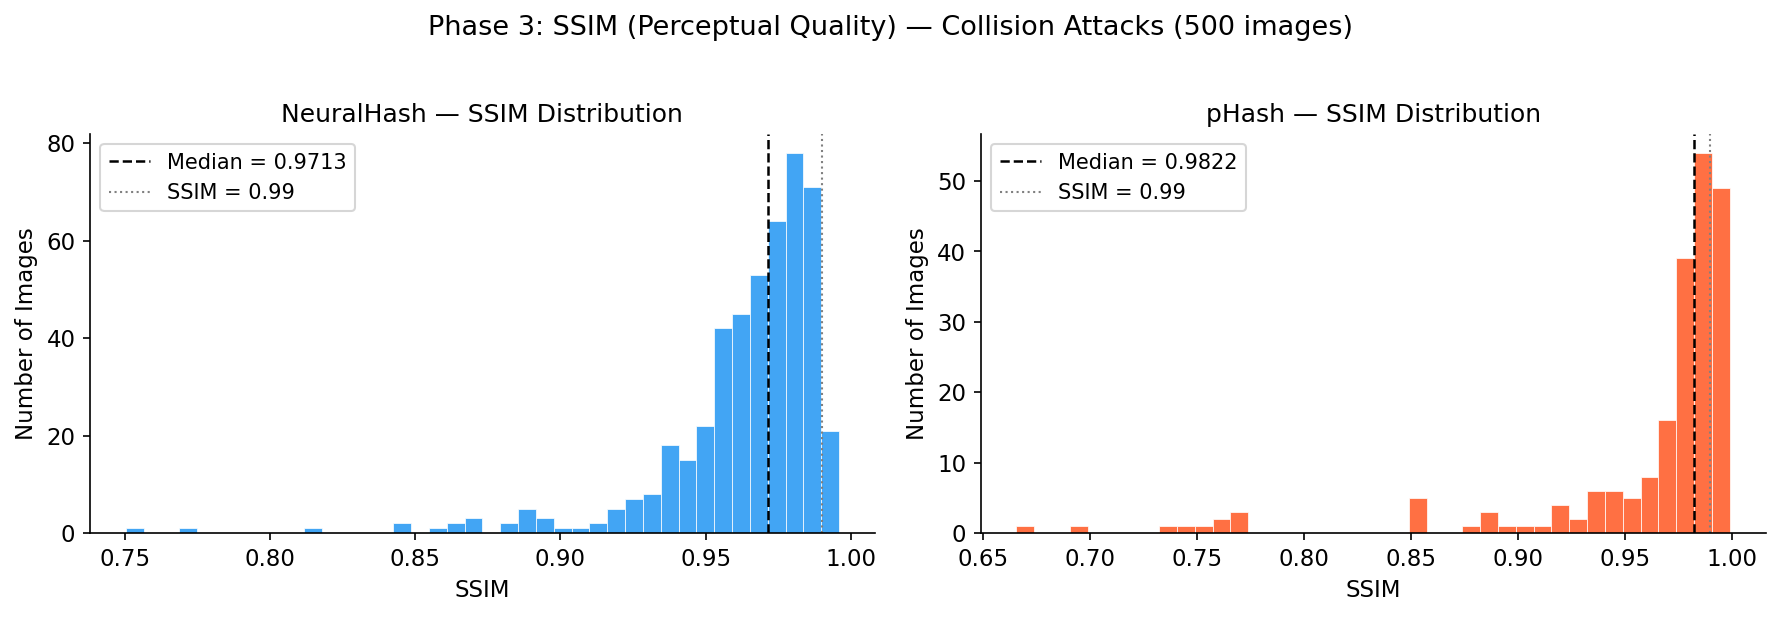

Saved: fdeph_eval/analysis/figures/collision_ssim_distribution.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, color, label in [
    (axes[0], nhash_col, NHASH_COLOR, 'NeuralHash'),
    (axes[1], phash_col, PHASH_COLOR, 'pHash'),
]:
    ax.hist(df['ssim'], bins=40, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
    ax.axvline(df['ssim'].median(), color='black', linestyle='--', linewidth=1.2,
               label=f'Median = {df["ssim"].median():.4f}')
    ax.axvline(0.99, color='gray', linestyle=':', linewidth=1.0, label='SSIM = 0.99')
    ax.set_title(f'{label} — SSIM Distribution')
    ax.set_xlabel('SSIM')
    ax.set_ylabel('Number of Images')
    ax.legend()

fig.suptitle('Phase 3: SSIM (Perceptual Quality) — Collision Attacks (500 images)', fontsize=13, y=1.02)
plt.tight_layout()
out = f'{FIGURES_DIR}/collision_ssim_distribution.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 8. NeuralHash vs pHash — Head-to-Head Collision Comparison

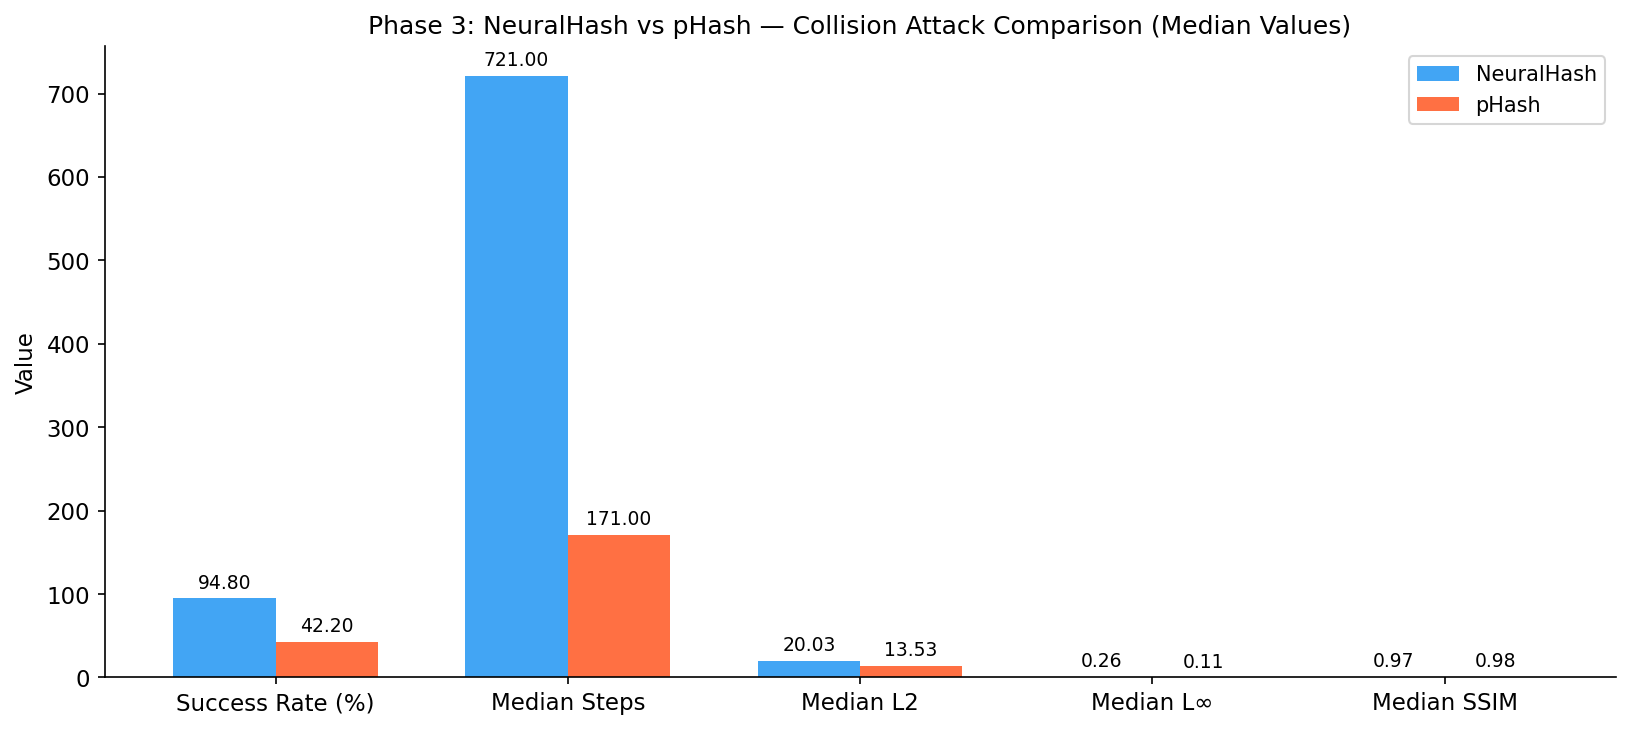

Saved: fdeph_eval/analysis/figures/collision_nhash_vs_phash_comparison.png


In [10]:
metrics = ['Success Rate (%)', 'Median Steps', 'Median L2', 'Median L∞', 'Median SSIM']
nhash_vals = [
    len(nhash_col) / TOTAL_IMAGES * 100,
    nhash_col['steps'].median(),
    nhash_col['l2'].median(),
    nhash_col['l_inf'].median(),
    nhash_col['ssim'].median(),
]
phash_vals = [
    len(phash_col) / TOTAL_IMAGES * 100,
    phash_col['steps'].median(),
    phash_col['l2'].median(),
    phash_col['l_inf'].median(),
    phash_col['ssim'].median(),
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, nhash_vals, width, label='NeuralHash', color=NHASH_COLOR, alpha=0.85)
bars2 = ax.bar(x + width/2, phash_vals, width, label='pHash',       color=PHASH_COLOR, alpha=0.85)

ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_title('Phase 3: NeuralHash vs pHash — Collision Attack Comparison (Median Values)')
ax.set_ylabel('Value')
ax.legend()

plt.tight_layout()
out = f'{FIGURES_DIR}/collision_nhash_vs_phash_comparison.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 9. Evasion vs Collision Cost — The Core Finding

This is the key cross-attack comparison: how much harder is collision than evasion for each algorithm?

In [11]:
# Evasion reference numbers from Phases 1 & 2 (T=0.10, 500 images)
# NeuralHash evasion: median 37 steps, 100% success
# pHash evasion:      median 13 steps, 100% success
NHASH_EVASION_STEPS_MEDIAN = 37
PHASH_EVASION_STEPS_MEDIAN = 13
NHASH_EVASION_SUCCESS      = 100.0
PHASH_EVASION_SUCCESS      = 100.0
NHASH_EVASION_L2           = None   # not directly comparable (different loss)
PHASH_EVASION_L2           = 1.364  # from Phase 2 results

nhash_col_steps_median = int(nhash_col['steps'].median())
phash_col_steps_median = int(phash_col['steps'].median())

nhash_ratio = nhash_col_steps_median / NHASH_EVASION_STEPS_MEDIAN
phash_ratio = phash_col_steps_median / PHASH_EVASION_STEPS_MEDIAN

print('=== Evasion vs Collision Cost Comparison ===')
print(f'{"":35} {"NeuralHash":>14} {"pHash":>14}')
print('-' * 65)
print(f'{"Evasion success rate":35} {NHASH_EVASION_SUCCESS:>13.1f}% {PHASH_EVASION_SUCCESS:>13.1f}%')
print(f'{"Evasion median steps":35} {NHASH_EVASION_STEPS_MEDIAN:>14} {PHASH_EVASION_STEPS_MEDIAN:>14}')
print(f'{"Collision success rate":35} {len(nhash_col)/TOTAL_IMAGES*100:>13.1f}% {len(phash_col)/TOTAL_IMAGES*100:>13.1f}%')
print(f'{"Collision median steps":35} {nhash_col_steps_median:>14} {phash_col_steps_median:>14}')
print(f'{"Collision / Evasion step ratio":35} {nhash_ratio:>13.1f}x {phash_ratio:>13.1f}x')
print()
print(f'NeuralHash: collision is {nhash_ratio:.1f}x harder than evasion (steps)')
print(f'pHash:      collision is {phash_ratio:.1f}x harder than evasion (steps)')

=== Evasion vs Collision Cost Comparison ===
                                        NeuralHash          pHash
-----------------------------------------------------------------
Evasion success rate                        100.0%         100.0%
Evasion median steps                            37             13
Collision success rate                       94.8%          42.2%
Collision median steps                         721            171
Collision / Evasion step ratio               19.5x          13.2x

NeuralHash: collision is 19.5x harder than evasion (steps)
pHash:      collision is 13.2x harder than evasion (steps)


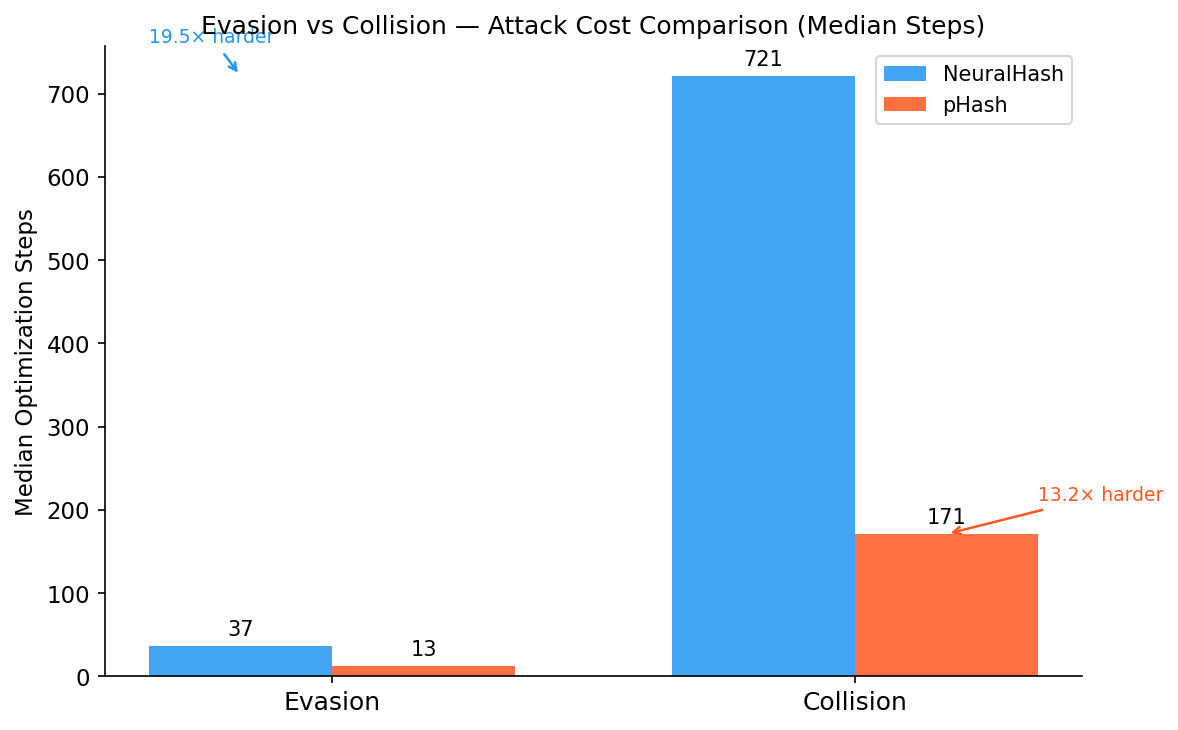

Saved: fdeph_eval/analysis/figures/collision_vs_evasion_steps_comparison.png


In [14]:
# ---- Grouped bar: evasion vs collision steps for each algorithm -------------
attack_types   = ['Evasion', 'Collision']
nhash_steps    = [NHASH_EVASION_STEPS_MEDIAN, nhash_col_steps_median]
phash_steps    = [PHASH_EVASION_STEPS_MEDIAN, phash_col_steps_median]

x = np.arange(len(attack_types))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, nhash_steps, width, label='NeuralHash', color=NHASH_COLOR, alpha=0.85)
b2 = ax.bar(x + width/2, phash_steps, width, label='pHash',       color=PHASH_COLOR, alpha=0.85)

ax.bar_label(b1, padding=3, fontsize=10)
ax.bar_label(b2, padding=3, fontsize=10)

# Annotate cost ratios
ax.annotate(f'{nhash_ratio:.1f}× harder',
            xy=(0 - width/2, nhash_col_steps_median), xytext=(-0.35, nhash_col_steps_median + 40),
            fontsize=9, color=NHASH_COLOR,
            arrowprops=dict(arrowstyle='->', color=NHASH_COLOR, lw=1.2))
ax.annotate(f'{phash_ratio:.1f}× harder',
            xy=(1 + width/2, phash_col_steps_median), xytext=(1.35, phash_col_steps_median + 40),
            fontsize=9, color=PHASH_COLOR,
            arrowprops=dict(arrowstyle='->', color=PHASH_COLOR, lw=1.2))

ax.set_xticks(x)
ax.set_xticklabels(attack_types, fontsize=12)
ax.set_ylabel('Median Optimization Steps')
ax.set_title('Evasion vs Collision — Attack Cost Comparison (Median Steps)')
ax.legend()

plt.tight_layout()
out = f'{FIGURES_DIR}/collision_vs_evasion_steps_comparison.png'
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

## 10. Full Four-Way Summary Table

NeuralHash evasion / NeuralHash collision / pHash evasion / pHash collision — all in one table.

In [15]:
four_way = pd.DataFrame([
    {
        'Attack':               'NeuralHash Evasion (T=0.10)',
        'Success rate (%)':     100.0,
        'Median steps':         37,
        'Median L2':            'N/A',
        'Median L∞':            '~0.04–0.08',
        'Median SSIM':          '>0.996',
        'Reference':            'Phase 1',
    },
    {
        'Attack':               'NeuralHash Collision',
        'Success rate (%)':     round(len(nhash_col) / TOTAL_IMAGES * 100, 1),
        'Median steps':         nhash_col_steps_median,
        'Median L2':            round(nhash_col['l2'].median(), 4),
        'Median L∞':            round(nhash_col['l_inf'].median(), 4),
        'Median SSIM':          round(nhash_col['ssim'].median(), 4),
        'Reference':            'Phase 3',
    },
    {
        'Attack':               'pHash Evasion (T=0.10)',
        'Success rate (%)':     100.0,
        'Median steps':         13,
        'Median L2':            1.364,
        'Median L∞':            0.0078,
        'Median SSIM':          0.9991,
        'Reference':            'Phase 2',
    },
    {
        'Attack':               'pHash Collision',
        'Success rate (%)':     round(len(phash_col) / TOTAL_IMAGES * 100, 1),
        'Median steps':         phash_col_steps_median,
        'Median L2':            round(phash_col['l2'].median(), 4),
        'Median L∞':            round(phash_col['l_inf'].median(), 4),
        'Median SSIM':          round(phash_col['ssim'].median(), 4),
        'Reference':            'Phase 3',
    },
])

four_way = four_way.set_index('Attack')
display(four_way)

out = f'{TABLES_DIR}/four_way_attack_comparison.csv'
four_way.to_csv(out)
print(f'Saved: {out}')

,Success rate (%),Median steps,Median L2,Median L∞,Median SSIM,Reference
Attack,,,,,,
NeuralHash Evasion (T=0.10),100.0,37,N/A,~0.04–0.08,>0.996,Phase 1
NeuralHash Collision,94.8,721,20.0273,0.2627,0.9713,Phase 3
pHash Evasion (T=0.10),100.0,13,1.364,0.0078,0.9991,Phase 2
pHash Collision,42.2,171,13.5301,0.1098,0.9822,Phase 3


Saved: fdeph_eval/analysis/tables/four_way_attack_comparison.csv


## 11. Comparison with Priyanka's NeuralHash Collision Baseline (CASIA)

In [16]:
# Priyanka's results from thesis (CASIA dataset, T=0.30)
# NeuralHash collision: 1435/1555 (92.28%), L2 range 10-30, up to 2000 steps
# NeuralHash evasion:   1555/1555 (100%),   mean L2=11.23

comparison = pd.DataFrame([
    {
        'Study':          'Priyanka (CASIA, T=0.30)',
        'Dataset':        'CASIA v2.0 test (1,555 images)',
        'Success rate (%)': 92.28,
        'Steps (max)':    2000,
        'L2 range':       '10–30 (mean ~11.23)',
        'SSIM':           '~1.0 (clustered)',
    },
    {
        'Study':          'Ours (ImageNette, no threshold)',
        'Dataset':        'ImageNette val (500 images)',
        'Success rate (%)': round(len(nhash_col) / TOTAL_IMAGES * 100, 1),
        'Steps (max)':    int(nhash_col['steps'].max()),
        'L2 range':       f'{nhash_col["l2"].min():.1f}–{nhash_col["l2"].max():.1f} (median {nhash_col["l2"].median():.2f})',
        'SSIM':           f'median {nhash_col["ssim"].median():.4f}',
    },
])

comparison = comparison.set_index('Study')
display(comparison)

out = f'{TABLES_DIR}/collision_priyanka_comparison.csv'
comparison.to_csv(out)
print(f'Saved: {out}')
print()
print('Note: Priyanka used exact hash match (distance=0) as success criterion — same as our protocol.')
print('Dataset difference (CASIA vs ImageNette) explains minor success rate variation.')

,Dataset,Success rate (%),Steps (max),L2 range,SSIM
Study,,,,,
"Priyanka (CASIA, T=0.30)","CASIA v2.0 test (1,555 images)",92.28,2000,10–30 (mean ~11.23),~1.0 (clustered)
"Ours (ImageNette, no threshold)",ImageNette val (500 images),94.80,9531,3.2–50.7 (median 20.03),median 0.9713


Saved: fdeph_eval/analysis/tables/collision_priyanka_comparison.csv

Note: Priyanka used exact hash match (distance=0) as success criterion — same as our protocol.
Dataset difference (CASIA vs ImageNette) explains minor success rate variation.


## 12. Collision Triplet Visualization [Original | Poisoned (Adversarial) | Diff×10 | Target]    

In [ ]:
# ============================================================
# Original | Poisoned (Adversarial) | Diff×10 | Target
# Shows 4 examples per algorithm, selected for diversity
# ============================================================

import sys
sys.path.insert(0, '.')

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, csv, io

# ---- Select examples from each collision log --------------------------------
def pick_examples(df, n=4):
    """Pick n diverse examples: fastest, best SSIM, worst SSIM, median steps."""
    df = df.copy().reset_index(drop=True)
    candidates = {
        'Fastest':      df.loc[df['steps'].idxmin()],
        'Best SSIM':    df.loc[df['ssim'].idxmax()],
        'Median steps': df.iloc[(df['steps'] - df['steps'].median()).abs().argsort().iloc[0]],
        'Worst SSIM':   df.loc[df['ssim'].idxmin()],
    }
    # Deduplicate by file
    seen, examples = set(), {}
    for label, row in candidates.items():
        key = row['file']
        if key not in seen:
            seen.add(key)
            examples[label] = row
    return examples


def load_rgb(path, size=224):
    """Load image as RGB numpy array, resized for display."""
    img = Image.open(path).convert('RGB').resize((size, size))
    return np.array(img)


def render_triplet_panel(examples, output_folder, title, out_path):
    """
    4 columns × 4 rows panel.
    Columns: Original | Poisoned | Diff×10 | Target
    Rows: one per selected example
    """
    col_labels = ['Original', 'Poisoned\n(Adversarial)', 'Difference ×10', 'Target\n(Hash Match)']
    n = len(examples)
    fig, axes = plt.subplots(n, 4, figsize=(14, 3.5 * n))
    if n == 1:
        axes = [axes]

    for row_idx, (example_label, row) in enumerate(examples.items()):
        # Reconstruct file paths
        base = os.path.splitext(os.path.basename(row['file']))[0]
        orig_path = os.path.join(output_folder, f'{base}.png')
        opt_path  = os.path.join(output_folder, f'{base}_opt.png')
        tgt_path  = os.path.join(output_folder, f'{base}_target.png')

        orig = load_rgb(orig_path)
        opt  = load_rgb(opt_path)
        tgt  = load_rgb(tgt_path)

        diff = np.clip((opt.astype(int) - orig.astype(int)) * 10 + 128, 0, 255).astype(np.uint8)

        imgs   = [orig, opt, diff, tgt]
        border = ['none', '#FF5722', '#FF5722', '#2196F3']

        for col_idx, (img, bc) in enumerate(zip(imgs, border)):
            ax = axes[row_idx][col_idx]
            ax.imshow(img)
            ax.axis('off')
            if bc != 'none':
                for spine in ax.spines.values():
                    spine.set_edgecolor(bc)
                    spine.set_linewidth(3)
                    spine.set_visible(True)
            if row_idx == 0:
                ax.set_title(col_labels[col_idx], fontsize=10, fontweight='bold')

        # Row label with key metrics
        axes[row_idx][0].set_ylabel(
            f'{example_label}\nL2={row["l2"]:.2f} | L∞={row["l_inf"]:.4f}\n'
            f'SSIM={row["ssim"]:.4f} | steps={int(row["steps"])}',
            fontsize=8, labelpad=6
        )

    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    # Legend
    legend_elements = [
        mpatches.Patch(facecolor='white', edgecolor='#FF5722', linewidth=2, label='Adversarial (poisoned)'),
        mpatches.Patch(facecolor='white', edgecolor='#2196F3', linewidth=2, label='Target (hash matched to)'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=2,
               bbox_to_anchor=(0.5, -0.02), fontsize=9)

    plt.tight_layout()
    plt.savefig(out_path, bbox_inches='tight', dpi=150)
    plt.show()
    print(f'Saved: {out_path}')


# ---- NeuralHash triplet panel -----------------------------------------------
nhash_examples = pick_examples(nhash_col)
render_triplet_panel(
    examples=nhash_examples,
    output_folder='collision_attack_outputs_nhash',
    title='NeuralHash Collision — Original | Poisoned | Difference×10 | Target',
    out_path=f'{FIGURES_DIR}/collision_nhash_triplet_panel.png'
)

# ---- pHash triplet panel ----------------------------------------------------
phash_examples = pick_examples(phash_col)
render_triplet_panel(
    examples=phash_examples,
    output_folder='collision_attack_outputs_phash',
    title='pHash Collision — Original | Poisoned | Difference×10 | Target',
    out_path=f'{FIGURES_DIR}/collision_phash_triplet_panel.png'
)

## 13 Hash Grid Visualization — Collision Edition

In [ ]:
# ============================================================
# For pHash: shows source hash, poisoned hash, target hash,
# XOR(source, poisoned), XOR(poisoned, target)
# XOR(poisoned, target) should be ALL GREEN (distance = 0)
# For NeuralHash: shows 96-bit hash as 8×12 grid
# ============================================================

import sys
sys.path.insert(0, '.')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch

# ---- pHash hash grid visualization ------------------------------------------
try:
    from utils.phash_torch import compute_phash_hard

    def bits_to_grid(hash_hex, grid_shape):
        """Convert hex hash string to 2D numpy grid of 0/1."""
        bits = bin(int(hash_hex, 16))[2:].zfill(len(hash_hex) * 4)
        arr = np.array([int(b) for b in bits], dtype=np.uint8)
        return arr.reshape(grid_shape)

    def draw_hash_grid(ax, grid, title, color_1='#1565C0', color_0='#E3F2FD',
                       highlight_color=None, highlight_mask=None):
        """Draw a hash bit grid on an axis."""
        rows, cols = grid.shape
        ax.set_xlim(0, cols)
        ax.set_ylim(0, rows)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(title, fontsize=8, pad=4)
        for r in range(rows):
            for c in range(cols):
                bit = grid[r, c]
                if highlight_mask is not None and highlight_mask[r, c]:
                    color = highlight_color
                else:
                    color = color_1 if bit == 1 else color_0
                rect = patches.Rectangle(
                    (c, rows - r - 1), 1, 1,
                    linewidth=0.3, edgecolor='#90A4AE', facecolor=color
                )
                ax.add_patch(rect)

    def phash_collision_grid_panel(row, output_folder, label):
        """
        6-column panel per image:
        Original | Poisoned | Target | Source hash | Poisoned hash | Target hash
        + XOR(source, poisoned) | XOR(poisoned, target)
        """
        base     = os.path.splitext(os.path.basename(row['file']))[0]
        orig_img = Image.open(os.path.join(output_folder, f'{base}.png')).convert('RGB')
        opt_img  = Image.open(os.path.join(output_folder, f'{base}_opt.png')).convert('RGB')
        tgt_img  = Image.open(os.path.join(output_folder, f'{base}_target.png')).convert('RGB')

        device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

        def img_to_tensor(pil_img):
            arr = np.array(pil_img.resize([360, 360])).astype(np.float32) / 255.0
            arr = arr * 2.0 - 1.0
            return torch.tensor(arr.transpose(2, 0, 1)).unsqueeze(0).to(device)

        _, src_hex, _  = compute_phash_hard(img_to_tensor(orig_img))
        _, opt_hex, _  = compute_phash_hard(img_to_tensor(opt_img))
        _, tgt_hex, _  = compute_phash_hard(img_to_tensor(tgt_img))

        src_grid = bits_to_grid(src_hex, (8, 8))
        opt_grid = bits_to_grid(opt_hex, (8, 8))
        tgt_grid = bits_to_grid(tgt_hex, (8, 8))

        xor_src_opt = src_grid ^ opt_grid   # bits that changed: source → poisoned
        xor_opt_tgt = opt_grid ^ tgt_grid   # bits still different: poisoned vs target (should be 0)

        src_opt_diff = int(xor_src_opt.sum())
        opt_tgt_diff = int(xor_opt_tgt.sum())

        fig, axes = plt.subplots(2, 5, figsize=(16, 6))

        # Row 1: images + hash grids
        size = 160
        axes[0, 0].imshow(np.array(orig_img.resize((size, size)))); axes[0, 0].axis('off')
        axes[0, 0].set_title('Original', fontsize=9, fontweight='bold')

        axes[0, 1].imshow(np.array(opt_img.resize((size, size)))); axes[0, 1].axis('off')
        axes[0, 1].set_title('Poisoned (Adversarial)', fontsize=9, fontweight='bold', color='#FF5722')

        axes[0, 2].imshow(np.array(tgt_img.resize((size, size)))); axes[0, 2].axis('off')
        axes[0, 2].set_title('Target (hash matched)', fontsize=9, fontweight='bold', color='#2196F3')

        # Metrics text panel
        axes[0, 3].axis('off')
        axes[0, 3].text(0.1, 0.5,
            f'L2 = {row["l2"]:.4f}\n'
            f'L∞ = {row["l_inf"]:.4f}\n'
            f'SSIM = {row["ssim"]:.4f}\n'
            f'Steps = {int(row["steps"])}\n\n'
            f'Bits changed\n(src→opt): {src_opt_diff}\n\n'
            f'Bits remaining\n(opt vs tgt): {opt_tgt_diff} ✓' if opt_tgt_diff == 0 else
            f'opt vs tgt: {opt_tgt_diff} bits',
            transform=axes[0, 3].transAxes,
            fontsize=9, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='#F5F5F5', alpha=0.8)
        )
        axes[0, 4].axis('off')

        # Row 2: hash grids
        draw_hash_grid(axes[1, 0], src_grid, f'Source hash\n{src_hex}')
        draw_hash_grid(axes[1, 1], opt_grid, f'Poisoned hash\n{opt_hex}',
                       highlight_color='#FF5722', highlight_mask=xor_src_opt)
        draw_hash_grid(axes[1, 2], tgt_grid, f'Target hash\n{tgt_hex}',
                       color_1='#2196F3', color_0='#E3F2FD')
        draw_hash_grid(axes[1, 3], xor_src_opt,
                       f'XOR: source ⊕ poisoned\n({src_opt_diff} bits flipped)',
                       color_1='#FF5722', color_0='#E8F5E9',
                       highlight_color='#FF5722', highlight_mask=xor_src_opt)
        draw_hash_grid(axes[1, 4], xor_opt_tgt,
                       f'XOR: poisoned ⊕ target\n({opt_tgt_diff} bits — should be 0)',
                       color_1='#E53935', color_0='#E8F5E9')

        fig.suptitle(
            f'pHash Collision — Hash Grid Analysis\n{label} | {base}',
            fontsize=11, fontweight='bold'
        )
        plt.tight_layout()
        out = f'{FIGURES_DIR}/collision_phash_hashgrid_{label.lower().replace(" ", "_")}.png'
        plt.savefig(out, bbox_inches='tight', dpi=150)
        plt.show()
        print(f'Saved: {out}')
        print(f'  Bits flipped (src→poisoned): {src_opt_diff}')
        print(f'  Bits diff (poisoned vs target): {opt_tgt_diff} — {"✅ exact match" if opt_tgt_diff == 0 else "⚠ mismatch"}')

    # Render for fastest and best SSIM examples
    for label, row in list(phash_examples.items())[:2]:
        phash_collision_grid_panel(row, 'collision_attack_outputs_phash', label)

except Exception as e:
    print(f'Hash grid visualization skipped: {e}')
    print('Ensure PYTHONPATH=. and utils/phash_torch.py is accessible.')

## 12. Artifact Summary

In [19]:
figures = [
    'collision_steps_histogram.png',
    'collision_success_rate_vs_steps.png',
    'collision_l2_distribution.png',
    'collision_linf_distribution.png',
    'collision_ssim_distribution.png',
    'collision_nhash_vs_phash_comparison.png',
    'collision_vs_evasion_steps_comparison.png',
]
tables = [
    'collision_summary_stats.csv',
    'four_way_attack_comparison.csv',
    'collision_priyanka_comparison.csv',
]

print('=== Figures ===')
for f in figures:
    path = os.path.join(FIGURES_DIR, f)
    status = 'PASS' if os.path.exists(path) else 'FAIL MISSING'
    print(f'  {status}  {path}')

print()
print('=== Tables ===')
for t in tables:
    path = os.path.join(TABLES_DIR, t)
    status = 'PASS' if os.path.exists(path) else 'FAIL MISSING'
    print(f'  {status}  {path}')

print()
print('Phase 3 analysis complete.')

=== Figures ===
  PASS  fdeph_eval/analysis/figures/collision_steps_histogram.png
  PASS  fdeph_eval/analysis/figures/collision_success_rate_vs_steps.png
  PASS  fdeph_eval/analysis/figures/collision_l2_distribution.png
  PASS  fdeph_eval/analysis/figures/collision_linf_distribution.png
  PASS  fdeph_eval/analysis/figures/collision_ssim_distribution.png
  PASS  fdeph_eval/analysis/figures/collision_nhash_vs_phash_comparison.png
  PASS  fdeph_eval/analysis/figures/collision_vs_evasion_steps_comparison.png

=== Tables ===
  PASS  fdeph_eval/analysis/tables/collision_summary_stats.csv
  PASS  fdeph_eval/analysis/tables/four_way_attack_comparison.csv
  PASS  fdeph_eval/analysis/tables/collision_priyanka_comparison.csv

Phase 3 analysis complete.
